# LangGraph ReAct Agent — Production-Shaped Reference (+ DevRev Prep Pointers)

**DevRev Technical Round, Section 3.** This is `langgraph_react_agent.py` converted to
a notebook, with the DevRev interview-prep pointers layered on top of its existing
structure. The original file's core logic is **unchanged**: the same tools, the same
`AgentState`, the same `build_from_scratch()` graph shape, the same `build_prebuilt()`
one-liner, and the same two-turn conversation demo. What's added:

- A real **confirmation gate** for a destructive tool, via LangGraph's `interrupt()` /
  `Command(resume=...)` human-in-the-loop primitive (the file only had a comment about
  this before — `interrupt_before=["tools"]` — this notebook actually wires it up,
  scoped to destructive tools only rather than every tool call)
- **Memoization** on `get_pipeline_metric` (a `functools.wraps`-based decorator — the
  tool's own lookup logic is untouched)
- **Retry with backoff** on a new `fetch_external_status` tool (simulated flaky
  dependency)
- **Fallback** to a backup path when a failure is permanent, not transient
- **Disambiguation** between two tools that could plausibly answer the same query
- **Observability** via a LangChain callback handler that traces every tool call

Already present in the original file and called out here rather than re-built:
**max-iteration guard** (`MAX_MODEL_STEPS` + `steps` in `AgentState`), **state across
turns** (the `checkpointer` + `thread_id`), and **parallel tool calls** (OpenAI's
`bind_tools` defaults `parallel_tool_calls=True`).

Uses `ChatOpenAI` / `OPENAI_API_KEY` (`gpt-4o-mini`). Swap `MODEL` for `gpt-4o` if you
want a stronger tool-calling model.

In [1]:
!pip install -U -qqqq langgraph langgraph-prebuilt "langchain>=1.0" langchain-openai
# Upgrading langgraph 0.2 -> 1.x can delete langgraph/prebuilt/*.py (pip uninstalls
# the old package after writing the new namespace). Reinstall so ToolNode exists.
!pip install -qqqq --force-reinstall --no-deps langgraph-prebuilt

## 0. Setup

In [2]:
# pip install -U langgraph langgraph-prebuilt "langchain>=1.0" langchain-openai

from __future__ import annotations

import ast
import functools
import operator
import os
import getpass
import time
from typing import Annotated, Literal, TypedDict

from langchain_openai import ChatOpenAI
from langchain_core.callbacks.base import BaseCallbackHandler
from langchain_core.messages import AIMessage, AnyMessage, SystemMessage, ToolMessage
from langchain_core.tools import tool
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import END, START, StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from langgraph.types import interrupt, Command

if not os.environ.get("OPENAI_API_KEY"):
    os.environ["OPENAI_API_KEY"] = getpass.getpass("OpenAI API key: ")

MODEL = "gpt-4o-mini"   # cheap + fast + supports tool calling; swap for gpt-4o if you like
MAX_MODEL_STEPS = 8  # hard budget: stops runaway tool loops before token spend explodes

SYSTEM_PROMPT = SystemMessage(
    content=(
        "You are a data platform assistant.\n"
        "- Use tools whenever a fact could be looked up or computed; never guess numbers.\n"
        "- You may call multiple tools in one turn when they are independent.\n"
        "- If a tool errors, read the error, fix your arguments, and retry at most once.\n"
        "- Destructive actions (closing an incident) require the user's explicit approval.\n"
        "- Finish with a short, direct answer that cites which tool produced each number."
    )
)

## 1. Tools

The original three tools (`calculator`, `search_knowledge_base`, `get_pipeline_metric`)
are unchanged in behavior. `get_pipeline_metric` gains a `@memoized` wrapper. Two new
tools cover the pointers the original file didn't touch: `close_incident` (destructive
→ confirmation gate) and `fetch_external_status` (flaky → retry).

Docstring + type hints are still the schema sent to the model — that part of the
original design doesn't change.

### Why `calculator()` uses `ast` instead of `eval()`

`ast.parse(expr, mode="eval")` turns the expression string into a tree of node
objects instead of executable bytecode. `_eval()` then walks that tree and only
ever interprets three node types — `ast.Constant`, `ast.BinOp`, `ast.UnaryOp` — so
nothing except numeric arithmetic can ever run. Anything else (names, calls,
attribute access, subscripts, comprehensions, ...) has no matching branch and
falls through to `raise ValueError`.

```python
expr = "(1240 - 870) / 870 * 100"
tree = ast.parse(expr, mode="eval").body
# -> BinOp(
#      left=BinOp(left=BinOp(Constant(1240), Sub, Constant(870)), Div, Constant(870)),
#      op=Mult, right=Constant(100)
#    )
_eval(tree)  # -> 42.5299...  (walks left/right recursively via _ALLOWED_OPS)
```

**Why not just `eval(expr)`?** Plain `eval()` executes *any* Python expression the
string contains — including calls, imports, and attribute access:

```python
eval("__import__('os').system('rm -rf /')")          # runs a shell command
eval("().__class__.__bases__[0].__subclasses__()")    # sandbox-escape gadget
```

If `expression` is an LLM-controlled tool argument (or influenced by untrusted
content the LLM read, i.e. prompt injection), `eval()` is a real RCE vector. The
`ast`-based whitelist turns the same payloads into a hard `ValueError` instead:

```python
calculator.invoke({"expression": "__import__('os').system('id')"})
# -> ast.Call has no matching branch in _eval -> ValueError, nothing executes
```

**Tradeoff:** more code than `str(eval(expression))`. Skip it in a throwaway
script you fully control; keep it whenever the input can be influenced by an
LLM or by content the LLM has read.

In [8]:
_ALLOWED_OPS = {
    ast.Add: operator.add,
    ast.Sub: operator.sub,
    ast.Mult: operator.mul,
    ast.Div: operator.truediv,
    ast.Pow: operator.pow,
    ast.Mod: operator.mod,
    ast.USub: operator.neg,
}


def _eval(node: ast.AST) -> float:
    if isinstance(node, ast.Constant) and isinstance(node.value, (int, float)):
        return node.value
    if isinstance(node, ast.BinOp) and type(node.op) in _ALLOWED_OPS:
        return _ALLOWED_OPS[type(node.op)](_eval(node.left), _eval(node.right))
    if isinstance(node, ast.UnaryOp) and type(node.op) in _ALLOWED_OPS:
        return _ALLOWED_OPS[type(node.op)](_eval(node.operand))
    raise ValueError("Unsupported expression: arithmetic literals and + - * / ** % only.")


@tool
def calculator(expression: str) -> str:
    """Evaluate an arithmetic expression and return the numeric result.

    Use for any arithmetic instead of computing mentally.
    Supports + - * / ** % and parentheses over numeric literals, e.g. "(1240 - 870) / 870 * 100".
    Raises ValueError on anything else (no names, no function calls).
    """
    return str(_eval(ast.parse(expression, mode="eval").body))


@tool
def search_knowledge_base(query: str, top_k: int = 3) -> str:
    """Semantic search over the internal engineering knowledge base.

    Use for questions about internal architecture, runbooks, and past incidents.
    Returns up to `top_k` chunks as "score | title | snippet" lines, best match first.
    Returns "NO_RESULTS" when nothing clears the relevance threshold — do not invent an answer then.
    """
    corpus = [
        (0.91, "Ingestion runbook", "Bronze autoloader retries 3x with exponential backoff."),
        (0.78, "Cost review Q2", "NRT pipeline runtime cut from 150 min to 87 min after repartition."),
        (0.64, "Streaming SLA", "p99 end-to-end latency target is 90 seconds."),
    ]
    hits = corpus[: max(1, min(top_k, len(corpus)))]
    return "\n".join(f"{s:.2f} | {t} | {snip}" for s, t, snip in hits) or "NO_RESULTS"

In [12]:
corpus = [
        (0.91, "Ingestion runbook", "Bronze autoloader retries 3x with exponential backoff."),
        (0.78, "Cost review Q2", "NRT pipeline runtime cut from 150 min to 87 min after repartition."),
        (0.64, "Streaming SLA", "p99 end-to-end latency target is 90 seconds."),
    ]
hits = corpus[: max(1, min(2, len(corpus)))]
result = "\n".join(f"{s:.2f} | {t} | {snip}" for s, t, snip in hits)
result

'0.91 | Ingestion runbook | Bronze autoloader retries 3x with exponential backoff.\n0.78 | Cost review Q2 | NRT pipeline runtime cut from 150 min to 87 min after repartition.'

### How the `@memoized` wrapper works

```python
_MEMO: dict[str, str] = {}

def memoized(fn):
    @functools.wraps(fn)
    def wrapper(*args, **kwargs):
        key = f"{fn.__name__}::{args}::{sorted(kwargs.items())}"
        if key in _MEMO:
            return _MEMO[key]
        result = _MEMO[key] = fn(*args, **kwargs)
        return result
    return wrapper

@tool
@memoized
def get_pipeline_metric(pipeline, metric): ...
```

**What it does at call time.** `memoized` is a decorator factory-free decorator: it
takes the real function `fn` and returns `wrapper` in its place. Every call to
`get_pipeline_metric(...)` actually calls `wrapper(...)`, which:

1. Builds a cache `key` from the function name plus its arguments — e.g.
   `"get_pipeline_metric::('nrt_ingest', 'runtime_min')::[]"` for a positional call,
   or with `kwargs` sorted so `{"a": 1, "b": 2}` and `{"b": 2, "a": 1}` hash to the
   same key.
2. If that exact `key` is already in the process-level `_MEMO` dict, returns the
   cached result immediately — `fn` never runs again.
3. Otherwise calls the real `fn`, stores the result in `_MEMO`, and returns it.

So the second time the agent asks for `get_pipeline_metric("nrt_ingest",
"runtime_min")` in the same process, it's a dict lookup instead of a (simulated, but
in production possibly slow/expensive) table query.

**This is the DevRev-prep pointer "memoize repeated tool calls with identical
arguments within a session."** The talking point: avoid redundant tool calls when
the same tool is asked with the same arguments more than once — repeat calls become
a free dict hit instead of re-running the (possibly expensive) lookup.

**Decorator stacking order — `@tool` then `@memoized`.** Decorators apply
bottom-up, so this is `tool(memoized(get_pipeline_metric))`: the *undecorated*
function is wrapped by `memoized` first, and the resulting `wrapper` is what
`@tool` turns into a LangChain tool. That ordering matters — `@tool` is what LangChain
calls when the model issues a tool call, so the cache check has to be the thing
`@tool` actually invokes, not bypassed by it.

**Why `functools.wraps(fn)` is load-bearing here, not just tidy.** Without it,
`wrapper.__name__` would be `"wrapper"` and `wrapper.__doc__` would be `None` — and
`@tool` builds the JSON schema the model sees (name, description, argument types) from
`inspect.signature`/`__doc__`/`__name__` of whatever function it's given.
`functools.wraps` copies `__name__`, `__doc__`, and sets `__wrapped__` to point back
at the original `fn`; `inspect.signature` follows `__wrapped__` automatically. Net
effect: the model still sees `get_pipeline_metric`'s real name, docstring, and
`(pipeline, metric)` signature — the memoization is completely invisible to it.

**Caveats worth knowing (interview-flavored):**
- **Unbounded, process-lifetime cache.** `_MEMO` is a plain module-level dict — it
  never evicts and never expires. Fine for a demo / a handful of pipelines; in
  production you'd want an LRU cache (`functools.lru_cache`, or an external cache
  with a TTL) so stale metrics don't get served forever and memory doesn't grow
  unbounded.
- **Caches exceptions too? No — it doesn't.** If `fn(*args, **kwargs)` raises (e.g.
  `get_pipeline_metric` with an unknown pipeline), the exception propagates before
  `_MEMO[key]` is ever assigned, so failed calls are correctly *not* cached and will
  retry cleanly next time.
- **No cross-process sharing.** `_MEMO` lives in this Python process's memory — a
  second worker process (e.g. another notebook kernel, or a horizontally scaled
  service) starts with a cold cache. That's the same tradeoff `functools.lru_cache`
  has; swap for Redis/Memcached if the cache needs to be shared.
- **Process-wide, not session-scoped — a real gap, not just a nitpick.** The intent
  ("memoize repeated tool calls with identical arguments *within a session*")
  implies the cache should be scoped to one conversation. But the cache key here is
  just `fn.__name__::args::kwargs` — it does **not** include `thread_id` (or any
  session identifier) anywhere. So in this notebook, `_MEMO` is actually shared
  across *every* `thread_id` running in the same process: `sourav-session-1` and
  `sourav-session-2` would silently hit the same cached entry for
  `get_pipeline_metric("nrt_ingest", "runtime_min")`. Harmless here since the
  underlying data is a static, non-per-user table — but in production, with
  per-user or time-sensitive data, that's a real bug: one user's cached result can
  leak into another user's session, and nothing expires it at a session boundary.
  The fix is to key the cache on `(thread_id, fn.__name__, args, kwargs)`, or hang a
  fresh cache dict off `AgentState` / the checkpointer instead of a module-level
  global.

In [13]:
# ---- memoization: a DevRev-prep pointer, bolted on without touching the lookup logic ----
_MEMO: dict[str, str] = {}


def memoized(fn):
    """Cache identical (tool, args) calls within the process.

    `functools.wraps` copies `__name__` / `__doc__` / `__wrapped__`, and `@tool` uses
    `inspect.signature`, which follows `__wrapped__` — so the JSON schema the model
    sees is still generated from the ORIGINAL function, not this wrapper.
    """
    @functools.wraps(fn)
    def wrapper(*args, **kwargs):
        key = f"{fn.__name__}::{args}::{sorted(kwargs.items())}"
        if key in _MEMO:
            return _MEMO[key]
        result = _MEMO[key] = fn(*args, **kwargs)
        return result
    return wrapper


@tool
@memoized
def get_pipeline_metric(pipeline: str, metric: Literal["runtime_min", "cost_usd", "rows"]) -> str:
    """Fetch the latest value of a metric for a named pipeline.

    Valid pipelines: "nrt_ingest", "batch_reconcile".
    Raises ValueError for unknown pipeline names — call search_knowledge_base to find the right name.
    """
    table = {
        "nrt_ingest": {"runtime_min": 87, "cost_usd": 412.50, "rows": 18_400_000},
        "batch_reconcile": {"runtime_min": 150, "cost_usd": 980.00, "rows": 42_100_000},
    }
    if pipeline not in table:
        raise ValueError(f"Unknown pipeline '{pipeline}'. Known: {list(table)}")
    return f"{pipeline}.{metric} = {table[pipeline][metric]}"


# ---- destructive tool: routed through the confirmation gate in Section 3 ----
DESTRUCTIVE_TOOLS = {"close_incident"}


@tool
def close_incident(pipeline: str, note: str) -> str:
    """Close (resolve) an open incident for a pipeline.

    DESTRUCTIVE: mutates on-call state. Never called directly by the graph below --
    it always passes through the confirmation gate first.
    """
    if pipeline not in {"nrt_ingest", "batch_reconcile"}:
        raise ValueError(f"Unknown pipeline '{pipeline}'.")
    return f"Incident for '{pipeline}' closed. Note: {note}"


# ---- flaky tool: demonstrates retry-with-backoff ----
class TransientError(Exception):
    """A temporary failure (timeout, 503) -- safe to RETRY."""


class PermanentError(Exception):
    """A permanent failure -- do NOT retry; consider a FALLBACK instead."""


def retry_transient(*, retries: int = 3, base_delay: float = 0.05):
    """Retry-with-backoff for TransientError only -- PermanentError is not retried."""
    def deco(fn):
        @functools.wraps(fn)
        def wrapper(*args, **kwargs):
            attempt = 0
            while True:
                try:
                    return fn(*args, **kwargs)
                except TransientError:
                    if attempt >= retries:
                        raise
                    attempt += 1
                    time.sleep(base_delay * attempt)
        return wrapper
    return deco


_external_status_calls = {"n": 0}


@tool
@retry_transient(retries=3)
def fetch_external_status(pipeline: str) -> str:
    """Check an external status API for a pipeline.

    Simulated as flaky on purpose: the first two calls raise a transient timeout so the
    retry decorator above has something to do.
    """
    _external_status_calls["n"] += 1
    if _external_status_calls["n"] <= 2:
        raise TransientError(f"external status API timeout (attempt {_external_status_calls['n']})")
    return f"{pipeline}: all systems normal"


TOOLS = [calculator, search_knowledge_base, get_pipeline_metric, close_incident, fetch_external_status]

## 2. State — unchanged

`add_messages` is a reducer: nodes return only the NEW messages and LangGraph appends
them (matching on id, so a re-emitted message updates in place). `steps` is a plain
int, so last write wins — exactly what a counter wants. `steps` is also what backs the
**max-iteration guard**: `agent_node` increments it every model call, and routing below
stops the loop once it hits `MAX_MODEL_STEPS`, regardless of what the model wants to do
next.

In [14]:
class AgentState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    steps: int

## 3. Confirmation gate — new

A node inserted between "agent" and "tools". If the model's last message requested a
**destructive** tool, it pauses the whole graph with `interrupt()` and waits for a
human decision; non-destructive calls pass straight through. Resuming happens with
`Command(resume=...)` against the same `thread_id`.

**Gotcha worth knowing:** `Command(resume=False)` is indistinguishable from "no resume
value" to LangGraph — `False` is falsy, so the framework treats the field as unset and
raises `EmptyInputError`. Always resume with a non-empty container (a dict) and read a
field out of it, never a bare bool.

In [15]:
def confirm_node(state: AgentState) -> dict:
    """Pause before any DESTRUCTIVE tool call and wait for human approval."""
    last = state["messages"][-1]
    destructive_calls = [tc for tc in getattr(last, "tool_calls", []) if tc["name"] in DESTRUCTIVE_TOOLS]
    if not destructive_calls:
        return {}

    decision = interrupt({
        "action": "confirm_destructive_tool_calls",
        "calls": [{"name": tc["name"], "args": tc["args"]} for tc in destructive_calls],
    })

    if not decision.get("approved"):
        denials = [
            ToolMessage(content="DENIED by user: destructive action not approved.",
                        tool_call_id=tc["id"])
            for tc in destructive_calls
        ]
        return {"messages": denials}
    return {}


def route_after_confirm(state: AgentState) -> Literal["tools", "agent"]:
    """If confirm_node wrote denial ToolMessages, every pending tool_call_id already has
    an answer -- skip the tools node and let the model react. Otherwise, run the tools."""
    last_ai = next(m for m in reversed(state["messages"]) if isinstance(m, AIMessage))
    pending_ids = {tc["id"] for tc in (last_ai.tool_calls or [])}
    answered_ids = {m.tool_call_id for m in state["messages"] if isinstance(m, ToolMessage)}
    if pending_ids and pending_ids.issubset(answered_ids):
        return "agent"
    return "tools"

## 4. Hand-rolled ReAct graph

Same shape as the original `build_from_scratch()`: `agent_node`, `ToolNode`, a step
budget. The only structural change is `route` (renamed `route_after_agent` since there
are now two routing decisions) points at the new `confirm` node instead of `tools`
directly, and the graph gains that node plus its edges.

In [16]:
def build_from_scratch(checkpointer=None):
    llm = ChatOpenAI(model=MODEL, temperature=0, max_tokens=2048)
    llm_with_tools = llm.bind_tools(TOOLS)  # parallel_tool_calls defaults on for OpenAI

    def agent_node(state: AgentState) -> dict:
        """Reason: one model call over the full transcript. This is the 'Thought' step."""
        response = llm_with_tools.invoke([SYSTEM_PROMPT, *state["messages"]])
        return {"messages": [response], "steps": state.get("steps", 0) + 1}

    # handle_tool_errors=True turns an exception into a ToolMessage the model can read
    # and self-correct from, instead of crashing the whole graph run.
    tool_node = ToolNode(TOOLS, handle_tool_errors=True)

    def route_after_agent(state: AgentState) -> Literal["confirm", "__end__"]:
        """Act-or-answer decision, now routing through the confirmation gate. The step
        budget is enforced here, same as the original `route`."""
        last = state["messages"][-1]
        if state.get("steps", 0) >= MAX_MODEL_STEPS:
            return END  # budget blown: return whatever the model has so far
        if getattr(last, "tool_calls", None):
            return "confirm"
        return END

    graph = (
        StateGraph(AgentState)
        .add_node("agent", agent_node)
        .add_node("confirm", confirm_node)
        .add_node("tools", tool_node)
        .add_edge(START, "agent")
        .add_conditional_edges("agent", route_after_agent, {"confirm": "confirm", END: END})
        .add_conditional_edges("confirm", route_after_confirm, {"tools": "tools", "agent": "agent"})
        .add_edge("tools", "agent")  # <- the loop that makes it ReAct
    )

    return graph.compile(checkpointer=checkpointer)

## 5. Prebuilt equivalent — unchanged

`langgraph.prebuilt.create_react_agent` still works but is deprecated in favour of
`langchain.agents.create_agent` (LangChain 1.x), which wraps the same loop plus
middleware. This is verbatim from the original file — the production path for adding
the confirmation gate / retry here would be
`HumanInTheLoopMiddleware` / a tool-level retry wrapper passed via `middleware=[...]`,
not a rewrite of this function.

In [17]:
def build_prebuilt(checkpointer=None):
    from langchain.agents import create_agent

    return create_agent(
        model=MODEL,
        tools=TOOLS,
        system_prompt=SYSTEM_PROMPT.content,
        checkpointer=checkpointer,
        # middleware=[SummarizationMiddleware(...), HumanInTheLoopMiddleware(...)]
    )

## 6. Fallback and disambiguation

Two more DevRev-prep pointers that don't need graph changes — they're orchestration
helpers you reach for explicitly around a tool call, same pattern as the sibling
`agent_tool_calling_demo_openai.ipynb`.

In [18]:
def call_with_fallback(primary_fn, fallback_fn, *args, **kwargs):
    """Try `primary_fn`; on a PermanentError, use `fallback_fn` instead."""
    try:
        return primary_fn(*args, **kwargs)
    except PermanentError as exc:
        print(f"[fallback] primary failed permanently ({exc}); using fallback")
        return fallback_fn(*args, **kwargs)


def disambiguate(candidates: list, query: str):
    """Deterministic tie-break when two tools could both plausibly answer a query.

    Prefers the non-destructive tool, then the one whose description shares the most
    words with the query. A real LLM usually disambiguates itself via good tool
    descriptions -- keep this as the safety net for when it's genuinely unsure.
    """
    words = set(query.lower().split())

    def score(t):
        overlap = len(words & set(t.description.lower().split()))
        return (0 if t.name in DESTRUCTIVE_TOOLS else 1, overlap)

    return max(candidates, key=score)

## 7. Observability

A `BaseCallbackHandler` that traces every tool call: what ran, its output, and its
latency. Pass it via `config={"callbacks": [tracer], ...}` on `.invoke()` / `.stream()`
— LangChain routes it down into `ToolNode`'s tool executions automatically, no changes
needed to the graph itself.

In [19]:
class ToolTraceHandler(BaseCallbackHandler):
    """Collects one record per tool call: status, output, latency in ms."""

    def __init__(self):
        self.records = []
        self._starts = {}

    def on_tool_start(self, serialized, input_str, *, run_id, **kwargs):
        self._starts[run_id] = time.perf_counter()

    def on_tool_end(self, output, *, run_id, **kwargs):
        ms = (time.perf_counter() - self._starts.pop(run_id, time.perf_counter())) * 1000
        content = getattr(output, "content", output)
        self.records.append({"status": "ok", "output": str(content), "ms": round(ms, 1)})

    def on_tool_error(self, error, *, run_id, **kwargs):
        ms = (time.perf_counter() - self._starts.pop(run_id, time.perf_counter())) * 1000
        self.records.append({"status": "error", "error": str(error), "ms": round(ms, 1)})

    def print_trace(self):
        if not self.records:
            print("(no tool calls)"); return
        print(f"{'#':>2}  {'status':<7} {'ms':>7}  output/error")
        print("-" * 70)
        for i, r in enumerate(self.records, 1):
            outcome = r.get("error", r.get("output"))
            print(f"{i:>2}  {r['status']:<7} {r['ms']:>7}  {outcome}")

## 8. Build the graph

Same as the original `main()`: a fresh `InMemorySaver` checkpointer (swap for
`SqliteSaver` / `PostgresSaver` in production), and print the compiled graph's ASCII
layout.

In [21]:
checkpointer = InMemorySaver()
app = build_from_scratch(checkpointer=checkpointer)
tracer = ToolTraceHandler()

# print(app.get_graph().draw_ascii())  # or .draw_mermaid()

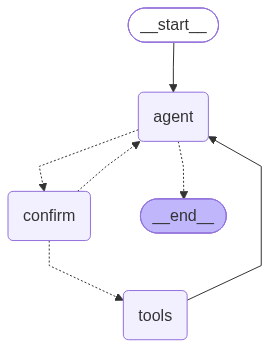

In [22]:
app

## 9. Demo — two turns, state across the conversation

The same demo as the original `main()`. The second turn ("And what's the cost
difference?") relies on the first turn's checkpointed history to know what "it" refers
to — the `thread_id` in `config` is what makes that possible.

In [23]:
config = {
    "configurable": {"thread_id": "sourav-session-1"},
    "recursion_limit": 25,       # graph-level superstep cap, separate from MAX_MODEL_STEPS
    "callbacks": [tracer],       # observability: every tool call gets traced
}

turns = [
    "By what percent is nrt_ingest faster than batch_reconcile on runtime?",
    "And what's the cost difference in dollars?",  # relies on checkpointed history
]

for user_msg in turns:
    print(f"\n=== USER: {user_msg}")
    for chunk in app.stream(
        {"messages": [{"role": "user", "content": user_msg}]},
        config=config,
        stream_mode="values",
    ):
        chunk["messages"][-1].pretty_print()


=== USER: By what percent is nrt_ingest faster than batch_reconcile on runtime?
================================ Human Message =================================

By what percent is nrt_ingest faster than batch_reconcile on runtime?


================================== Ai Message ==================================
Tool Calls:
  get_pipeline_metric (call_mhts0tjHJBKnKuDdRP4LGtxf)
 Call ID: call_mhts0tjHJBKnKuDdRP4LGtxf
  Args:
    pipeline: nrt_ingest
    metric: runtime_min
  get_pipeline_metric (call_pzmhWbDXlAzwLmVaknnzLGoS)
 Call ID: call_pzmhWbDXlAzwLmVaknnzLGoS
  Args:
    pipeline: batch_reconcile
    metric: runtime_min
================================= Tool Message =================================
Name: get_pipeline_metric

batch_reconcile.runtime_min = 150


================================== Ai Message ==================================
Tool Calls:
  calculator (call_AlddJjX5V4qwHoALgfQNhnT7)
 Call ID: call_AlddJjX5V4qwHoALgfQNhnT7
  Args:
    expression: ((150 - 87) / 150) * 100
================================= Tool Message =================================
Name: calculator

42.0


================================== Ai Message ==================================

The nrt_ingest pipeline is 42% faster than the batch_reconcile pipeline in terms of runtime. This was calculated using the runtime values of 87 minutes for nrt_ingest and 150 minutes for batch_reconcile.

=== USER: And what's the cost difference in dollars?
================================ Human Message =================================

And what's the cost difference in dollars?


================================== Ai Message ==================================
Tool Calls:
  get_pipeline_metric (call_djsTmoYFnl8P6xkzqwDho03d)
 Call ID: call_djsTmoYFnl8P6xkzqwDho03d
  Args:
    pipeline: nrt_ingest
    metric: cost_usd
  get_pipeline_metric (call_W3YZGlcw3ZUhV0qRsRAlIThb)
 Call ID: call_W3YZGlcw3ZUhV0qRsRAlIThb
  Args:
    pipeline: batch_reconcile
    metric: cost_usd
================================= Tool Message =================================
Name: get_pipeline_metric

batch_reconcile.cost_usd = 980.0


================================== Ai Message ==================================
Tool Calls:
  calculator (call_FF6HFAumvTjaftHO5UdFEAW8)
 Call ID: call_FF6HFAumvTjaftHO5UdFEAW8
  Args:
    expression: 980.0 - 412.5
================================= Tool Message =================================
Name: calculator

567.5
================================== Ai Message ==================================

The cost difference between the batch_reconcile and nrt_ingest pipelines is $567.50, with batch_reconcile costing $980.00 and nrt_ingest costing $412.50.


## 10. Demo — the confirmation gate

Ask the agent to close an incident. `close_incident` is destructive, so `confirm_node`
pauses the graph instead of running it. Check `get_state(...).tasks[*].interrupts` to
see the pending decision (more robust across LangGraph versions than looking for an
`"__interrupt__"` key on the return value), then resume with an explicit approval.

In [24]:
close_config = {"configurable": {"thread_id": "sourav-session-2"}, "callbacks": [tracer]}

for chunk in app.stream(
    {"messages": [{"role": "user", "content": "Close the incident for nrt_ingest, note: resolved after redeploy."}]},
    config=close_config,
    stream_mode="values",
):
    chunk["messages"][-1].pretty_print()

state = app.get_state(close_config)
pending = [t for t in state.tasks if t.interrupts]
if pending:
    print("\nPAUSED — pending confirmation:")
    print(pending[0].interrupts[0].value)

================================ Human Message =================================

Close the incident for nrt_ingest, note: resolved after redeploy.
================================== Ai Message ==================================

I need your explicit approval to close the incident for the nrt_ingest pipeline with the note "resolved after redeploy." Do you want to proceed?


Approve it, and the same turn picks up where it left off:

In [26]:
for chunk in app.stream(Command(resume={"approved": True}), config=close_config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================== Ai Message ==================================

I need your explicit approval to close the incident for the nrt_ingest pipeline with the note "resolved after redeploy." Do you want to proceed?


## 11. Demo — retry and fallback

`fetch_external_status` fails twice with a `TransientError`, then succeeds — the
`retry_transient` decorator makes that invisible to the model. Separately,
`call_with_fallback` shows what happens when a failure is **permanent** instead: no
amount of retrying helps, so the orchestration layer reroutes to a backup path.

In [ ]:
retry_config = {"configurable": {"thread_id": "sourav-session-3"}, "callbacks": [tracer]}

for chunk in app.stream(
    {"messages": [{"role": "user", "content": "What's the external status of nrt_ingest?"}]},
    config=retry_config,
    stream_mode="values",
):
    chunk["messages"][-1].pretty_print()

In [27]:
def primary_lookup(pipeline):
    raise PermanentError(f"external status service has no record for '{pipeline}'")

def fallback_lookup(pipeline):
    return get_pipeline_metric.invoke({"pipeline": pipeline, "metric": "runtime_min"})

result = call_with_fallback(primary_lookup, fallback_lookup, "nrt_ingest")
print(result)

[fallback] primary failed permanently (external status service has no record for 'nrt_ingest'); using fallback
nrt_ingest.runtime_min = 87


## 12. Demo — disambiguation

If a query could plausibly be answered by either `get_pipeline_metric` or
`close_incident`, don't let a tie default to the destructive one.

In [28]:
choice = disambiguate([get_pipeline_metric, close_incident], "check on the nrt_ingest pipeline")
print("chosen tool:", choice.name)

chosen tool: get_pipeline_metric


## 13. Observability — the full trace

Every tool call across every demo above, in order — what ran, what it returned, and how
long it took. In production this is exactly the shape of an OpenTelemetry span or a
LangSmith trace entry.

In [29]:
tracer.print_trace()

 #  status       ms  output/error
----------------------------------------------------------------------
 1  ok          0.9  nrt_ingest.runtime_min = 87
 2  ok          1.0  batch_reconcile.runtime_min = 150
 3  ok          1.0  42.0
 4  ok          0.8  nrt_ingest.cost_usd = 412.5
 5  ok          0.9  batch_reconcile.cost_usd = 980.0
 6  ok          0.8  567.5


## 14. Design talking points (say these out loud)

**State management across turns**
The `checkpointer` (here `InMemorySaver`, in production `SqliteSaver` / `PostgresSaver`)
keyed by `thread_id` IS the conversation store — no separate `Session` object needed,
because LangGraph persists the whole state dict (`messages`, `steps`) after every
superstep. That's what makes `Command(resume=...)` possible after a confirmation pause,
even across a process restart.

**Parallel vs. sequential tool calls**
OpenAI's `bind_tools` defaults `parallel_tool_calls=True` (`openai >= 1.32`), so when
the model asks for two independent facts (e.g. two different pipelines' metrics), both
`tool_calls` land in the same `AIMessage` and `ToolNode` executes them together — no
extra code needed here, unlike the raw-loop version in
`agent_tool_calling_demo_openai.ipynb` where that fan-out is hand-rolled with a
`ThreadPoolExecutor`.

**Failure policy**
Transient (timeout / 503) → retry with backoff (`retry_transient`). Permanent, with a
backup path available → fall back (`call_with_fallback`). No fallback → let
`handle_tool_errors=True` turn it into a `ToolMessage` so the model can explain the
failure to the user instead of crashing the graph.

**Confirmation gate**
Enforced by `confirm_node`, not left to the model's judgment or the system prompt —
even a model that ignores the "requires approval" instruction in `SYSTEM_PROMPT` can't
actually run `close_incident` without `interrupt()` being satisfied first.

**Max-iteration guard**
`MAX_MODEL_STEPS` bounds how many times the model gets invoked, independent of
`recursion_limit` (which is LangGraph's own graph-superstep safety net — a second,
coarser backstop).

## 15. Recap — what maps to what

| Interview bullet | Where it lives |
|---|---|
| Tool registry (name, description, schema) | Section 1 — `@tool` decorators |
| ReAct loop: think / act / observe | Section 4 — `build_from_scratch` |
| Max-iteration guard | `MAX_MODEL_STEPS`, `AgentState.steps` (original file) |
| State across conversation turns | `checkpointer` + `thread_id` (original file) |
| Parallel vs. sequential tool calls | OpenAI `parallel_tool_calls` (original file); Section 14 |
| Confirmation gate before destructive tools | Section 3 — `confirm_node`, `interrupt()` / `Command`; Demo in Section 10 |
| Memoization of repeated calls | Section 1 — `memoized` on `get_pipeline_metric` |
| Retry on transient failures | Section 1 — `retry_transient` on `fetch_external_status`; Demo in Section 11 |
| Fallback to a backup path | Section 6 — `call_with_fallback`; Demo in Section 11 |
| Disambiguating two plausible tools | Section 6 — `disambiguate`; Demo in Section 12 |
| Observability / tool-call logging | Section 7 — `ToolTraceHandler`; Section 13 |

For the same ideas built without any framework (a raw `while` loop, real OpenAI tool
calling) see `agent_tool_calling_demo_openai.ipynb` in this folder; for the fully
modular `src/`-package version with an offline rule-based brain, see
`agent_tool_calling_demo.ipynb`.